In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

## Load data and compute extreme rates by CADD decile

In [2]:
# Load olink whitelist
burden_test = pl.read_parquet('/home/dnanexus/data_dir/proteomics_prs_df_loftee_mac20_burden_regression_results.parquet')
olink_whitelist = burden_test.rename({'gene': 'region'}).select(['region']).unique()

print(f"Olink whitelist: {olink_whitelist.shape[0]} genes")

Olink whitelist: 2659 genes


In [3]:
# Load annotations - filter to missense SNPs in olink genes
anno = pl.read_parquet('/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet')

anno_missense = (
    anno
    .filter(
        (pl.col('region').is_in(olink_whitelist['region'])) &
        (pl.col('consequence_missense_variant') == True) &
        (pl.col('ref').str.len_chars() == 1) &
        (pl.col('alt').str.len_chars() == 1)
    )
    .select(['id', 'region', 'cadd_raw'])
    .drop_nulls('cadd_raw')
)

print(f"Missense SNPs: {anno_missense.shape[0]:,}")

/tmp/ipykernel_320569/816289086.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(


Missense SNPs: 782,312


In [4]:
# Load APPV
appv = pl.read_parquet('/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet')

appv_filtered = appv.filter(pl.col('n_individuals') <= 20)
print(f"APPV filtered (≤20 individuals): {appv_filtered.shape[0]:,}")

APPV filtered (≤20 individuals): 5,084,046


In [6]:
# Join with missense annotations and add CADD
appv_missense = (
    appv_filtered
    .join(anno_missense, on=['id'], how='inner')
)

print(f"APPV-missense with CADD: {appv_missense.shape[0]:,}")

APPV-missense with CADD: 88,326


In [7]:
# Add extreme flag (ptile >= 0.99 for olink bottom extremes)
appv_missense = appv_missense.with_columns(
    is_extreme = pl.col('mean_pheno_value_ptile') >= 0.99
)

total = appv_missense.shape[0]
extreme = appv_missense.filter(pl.col('is_extreme')).shape[0]

print(f"\n=== OVERALL RATES ===")
print(f"Total missense variant-phenotype pairs: {total:,}")
print(f"Extreme (ptile ≥ 0.99): {extreme:,}")
print(f"Overall extreme rate: {extreme / total * 100:.2f}%")


=== OVERALL RATES ===
Total missense variant-phenotype pairs: 88,326
Extreme (ptile ≥ 0.99): 9,600
Overall extreme rate: 10.87%


In [12]:
# Bin by CADD score deciles
appv_missense = appv_missense.with_columns(
    cadd_decile = pl.col('cadd_raw').qcut(9, labels=[f"D{i}" for i in range(1, 10)])
)

# Compute extreme rate per decile
extreme_by_decile = (
    appv_missense
    .group_by('cadd_decile')
    .agg(
        n_total = pl.len(),
        n_extreme = pl.col('is_extreme').sum(),
        cadd_min = pl.col('cadd_raw').min(),
        cadd_max = pl.col('cadd_raw').max(),
    )
    .with_columns(
        extreme_rate = (pl.col('n_extreme') / pl.col('n_total') * 100)
    )
    .sort('cadd_decile')
)

print("\n=== EXTREME RATE BY CADD DECILE ===")
extreme_by_decile


=== EXTREME RATE BY CADD DECILE ===


cadd_decile,n_total,n_extreme,cadd_min,cadd_max,extreme_rate
cat,u64,u64,f32,f32,f64
"""D1""",9814,327,-4.82243,0.500152,3.331975
"""D2""",9814,390,0.500277,1.447498,3.973915
"""D3""",9814,550,1.447534,2.246431,5.604239
"""D4""",9814,679,2.246591,2.926172,6.918688
"""D5""",9814,813,2.926347,3.522288,8.284084
"""D6""",9815,1084,3.52249,4.073993,11.04432
"""D7""",9813,1453,4.074009,4.566613,14.806889
"""D8""",9814,1899,4.566615,5.044778,19.349908
"""D9""",9814,2405,5.044805,10.227507,24.505808


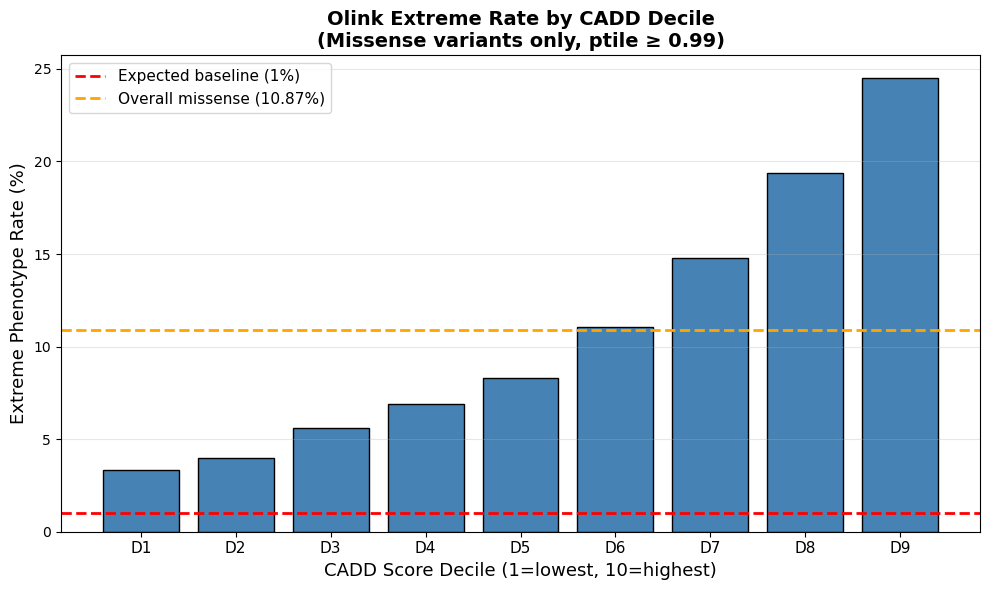

✓ Saved plot


In [14]:
# Plot 1: Extreme rate by CADD decile
fig, ax = plt.subplots(figsize=(10, 6))

decile_data = extreme_by_decile.to_pandas()
ax.bar(range(len(decile_data)), decile_data['extreme_rate'], color='steelblue', edgecolor='black')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Expected baseline (1%)')
ax.axhline(y=extreme / total * 100, color='orange', linestyle='--', linewidth=2,
           label=f'Overall missense ({extreme / total * 100:.2f}%)')

ax.set_xlabel('CADD Score Decile (1=lowest, 10=highest)', fontsize=13)
ax.set_ylabel('Extreme Phenotype Rate (%)', fontsize=13)
ax.set_title('Olink Extreme Rate by CADD Decile\n(Missense variants only, ptile ≥ 0.99)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(decile_data)))
ax.set_xticklabels([f"D{i}" for i in range(1, len(decile_data)+1)], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/home/dnanexus/ukbgym/debug_olink_extreme_by_cadd.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved plot")

In [ ]:
# Compute ORs
print("\n=== ODDS RATIO COMPARISONS ===")

top_decile = extreme_by_decile.filter(pl.col('cadd_decile') == 'D10')
bottom_decile = extreme_by_decile.filter(pl.col('cadd_decile') == 'D1')

top_rate = top_decile['extreme_rate'].item()
bottom_rate = bottom_decile['extreme_rate'].item()
overall_rate = extreme / total * 100

print(f"\nTop 10% CADD (D10) extreme rate: {top_rate:.2f}%")
print(f"Bottom 10% CADD (D1) extreme rate: {bottom_rate:.2f}%")
print(f"Overall missense extreme rate: {overall_rate:.2f}%")

print(f"\nContinuous OR (top CADD vs bottom CADD): {top_rate / bottom_rate:.2f}")
print(f"  = {top_rate:.2f}% / {bottom_rate:.2f}%")

print(f"\nCategory OR (missense vs 1% baseline): {overall_rate / 1.0:.2f}")
print(f"  = {overall_rate:.2f}% / 1.0%")

print(f"\n❓ KEY QUESTION: Why is bottom decile extreme rate {bottom_rate:.2f}% instead of 1%?")